In [37]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

In [38]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [39]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [40]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [41]:
#data cleaning
play_store_df = play_store_df.dropna(subset=['Rating'])
for column in play_store_df.columns:
    play_store_df[column].fillna(play_store_df[column].mode()[0], inplace=True)

play_store_df.drop_duplicates(inplace=True)

play_store_df = play_store_df[play_store_df['Rating'] <= 5]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21592\1218669340.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  play_store_df[column].fillna(play_store_df[column].mode()[0], inplace=True)


In [42]:
reviews_df.dropna(subset=['Translated_Review'], inplace=True)

In [43]:
#converts installs column
play_store_df["Installs_Num"] = (
    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

play_store_df["Installs_Num"] = pd.to_numeric(
    play_store_df["Installs_Num"],
    errors="coerce"
)

In [44]:
play_store_df[["Installs", "Installs_Num"]].head()

,Installs,Installs_Num
0,"10,000+",10000
1,"500,000+",500000
2,"5,000,000+",5000000
3,"50,000,000+",50000000
4,"100,000+",100000


In [45]:
#mergingboth csv files
merged_df = pd.merge(
    play_store_df,
    reviews_df,
    on="App",
    how="inner"
)

In [46]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,I hate,Negative,-0.800,0.900000


In [47]:
merged_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Installs_Num', 'Translated_Review', 'Sentiment',
       'Sentiment_Polarity', 'Sentiment_Subjectivity'],
      dtype='str')

In [48]:
#filtering the data
filtered_df = merged_df[
    merged_df["Category"].str.startswith(("B", "C", "E"))
]
filtered_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
671,"BestCam Selfie-selfie, beauty camera, photo ed...",BEAUTY,3.9,1739,21M,"500,000+",Free,0,Everyone,Beauty,"July 12, 2018",1.0.6,4.0.3 and up,500000,This a̸p̸p̸ Na Kare please Mere Bhai A L pleas...,Negative,-0.500000,0.950000
672,"BestCam Selfie-selfie, beauty camera, photo ed...",BEAUTY,3.9,1739,21M,"500,000+",Free,0,Everyone,Beauty,"July 12, 2018",1.0.6,4.0.3 and up,500000,Worst lot add; time west,Negative,-1.000000,1.000000
673,"BestCam Selfie-selfie, beauty camera, photo ed...",BEAUTY,3.9,1739,21M,"500,000+",Free,0,Everyone,Beauty,"July 12, 2018",1.0.6,4.0.3 and up,500000,bed bakvas time west stupid,Negative,-0.800000,1.000000
674,"BestCam Selfie-selfie, beauty camera, photo ed...",BEAUTY,3.9,1739,21M,"500,000+",Free,0,Everyone,Beauty,"July 12, 2018",1.0.6,4.0.3 and up,500000,It bad dont install worst,Negative,-0.850000,0.833333
675,"BestCam Selfie-selfie, beauty camera, photo ed...",BEAUTY,3.9,1739,21M,"500,000+",Free,0,Everyone,Beauty,"July 12, 2018",1.0.6,4.0.3 and up,500000,Fake install best sweet selfie,Positive,0.283333,0.650000


In [49]:
filtered_df["Category"].unique()

<ArrowStringArray>
[             'BEAUTY', 'BOOKS_AND_REFERENCE',            'BUSINESS',
              'COMICS',       'COMMUNICATION',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS']
Length: 8, dtype: str

In [50]:
filtered_df["Reviews"] = pd.to_numeric(
    filtered_df["Reviews"],
    errors="coerce"
)

In [51]:
filtered_df = filtered_df[
    filtered_df["Reviews"] > 500
]
filtered_df["Reviews"].head()

671    1739
672    1739
673    1739
674    1739
675    1739
Name: Reviews, dtype: int64

In [52]:
filtered_df = filtered_df[
    ~filtered_df["App"].str.startswith(("X", "Y", "Z"))
]

In [53]:
filtered_df = filtered_df[
    ~filtered_df["App"].str.contains("S", case=False, na=False)
]

In [54]:
translation_dict = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Partnersuche"
}

filtered_df["Display_Category"] = (
    filtered_df["Category"].replace(translation_dict)
)

In [55]:
filtered_df[["Category", "Display_Category"]].head(100)

,Category,Display_Category
1009,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1010,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1011,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1012,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1013,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
...,...,...
1104,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1105,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1106,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE
1107,BOOKS_AND_REFERENCE,BOOKS_AND_REFERENCE


In [56]:
filtered_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Installs_Num', 'Translated_Review', 'Sentiment',
       'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Display_Category'],
      dtype='str')

In [57]:
filtered_df[
    filtered_df["Category"].isin(["BEAUTY", "BUSINESS", "DATING"])
][["Category", "Display_Category"]]

,Category,Display_Category
1790,BUSINESS,வணிகம்
1791,BUSINESS,வணிகம்
1826,BUSINESS,வணிகம்
1827,BUSINESS,வணிகம்
1828,BUSINESS,வணிகம்
...,...,...
1941,BUSINESS,வணிகம்
1942,BUSINESS,வணிகம்
1943,BUSINESS,வணிகம்
1944,BUSINESS,வணிகம்


In [58]:
#last update to date time
filtered_df["Last Updated"] = pd.to_datetime(
    filtered_df["Last Updated"],
    errors="coerce"
)

In [59]:
filtered_df["Last Updated"].head(6)

1009   2018-07-27
1010   2018-07-27
1011   2018-07-27
1012   2018-07-27
1013   2018-07-27
1014   2018-07-27
Name: Last Updated, dtype: datetime64[us]

In [60]:
#extract month and year
filtered_df["Month"] = (
    filtered_df["Last Updated"].dt.to_period("M")
)
filtered_df[["Last Updated", "Month"]].head(6)

,Last Updated,Month
1009,2018-07-27,2018-07
1010,2018-07-27,2018-07
1011,2018-07-27,2018-07
1012,2018-07-27,2018-07
1013,2018-07-27,2018-07
1014,2018-07-27,2018-07


In [61]:
monthly_installs = (
    filtered_df.groupby(
        ["Month", "Display_Category"]
    )["Installs_Num"]
    .sum()
    .reset_index()
)
monthly_installs.head(6)

,Month,Display_Category,Installs_Num
0,2014-07,COMMUNICATION,340000000
1,2015-01,EDUCATION,3700000
2,2015-06,EDUCATION,35000000
3,2015-07,BOOKS_AND_REFERENCE,380000000
4,2015-08,EDUCATION,36000000
5,2016-06,COMMUNICATION,1000000


In [62]:
monthly_installs = monthly_installs.sort_values(
    by=["Display_Category", "Month"]
)
monthly_installs.head(20)

,Month,Display_Category,Installs_Num
3,2015-07,BOOKS_AND_REFERENCE,380000000
9,2017-08,BOOKS_AND_REFERENCE,400000000
11,2018-05,BOOKS_AND_REFERENCE,195000000
13,2018-06,BOOKS_AND_REFERENCE,585000000
17,2018-07,BOOKS_AND_REFERENCE,23437000000
22,2018-08,BOOKS_AND_REFERENCE,9700000000
0,2014-07,COMMUNICATION,340000000
5,2016-06,COMMUNICATION,1000000
14,2018-06,COMMUNICATION,70000000
18,2018-07,COMMUNICATION,5334000000


In [63]:
monthly_installs["Growth_Percentage"] = (
    monthly_installs.groupby("Display_Category")["Installs_Num"]
    .pct_change() * 100
)
monthly_installs.head(18)

,Month,Display_Category,Installs_Num,Growth_Percentage
3,2015-07,BOOKS_AND_REFERENCE,380000000,NaN
9,2017-08,BOOKS_AND_REFERENCE,400000000,5.263158
11,2018-05,BOOKS_AND_REFERENCE,195000000,-51.250000
13,2018-06,BOOKS_AND_REFERENCE,585000000,200.000000
17,2018-07,BOOKS_AND_REFERENCE,23437000000,3906.324786
22,2018-08,BOOKS_AND_REFERENCE,9700000000,-58.612450
0,2014-07,COMMUNICATION,340000000,NaN
5,2016-06,COMMUNICATION,1000000,-99.705882
14,2018-06,COMMUNICATION,70000000,6900.000000
18,2018-07,COMMUNICATION,5334000000,7520.000000


In [64]:
monthly_installs["Significant_Growth"] = (
    monthly_installs["Growth_Percentage"] > 20
)
monthly_installs.head(12)

,Month,Display_Category,Installs_Num,Growth_Percentage,Significant_Growth
3,2015-07,BOOKS_AND_REFERENCE,380000000,NaN,False
9,2017-08,BOOKS_AND_REFERENCE,400000000,5.263158,False
11,2018-05,BOOKS_AND_REFERENCE,195000000,-51.250000,False
13,2018-06,BOOKS_AND_REFERENCE,585000000,200.000000,True
17,2018-07,BOOKS_AND_REFERENCE,23437000000,3906.324786,True
22,2018-08,BOOKS_AND_REFERENCE,9700000000,-58.612450,False
0,2014-07,COMMUNICATION,340000000,NaN,False
5,2016-06,COMMUNICATION,1000000,-99.705882,False
14,2018-06,COMMUNICATION,70000000,6900.000000,True
18,2018-07,COMMUNICATION,5334000000,7520.000000,True


In [65]:
import plotly.express as px
fig = px.line(
    monthly_installs,
    x="Month",
    y="Installs_Num",
    color="Display_Category",
    markers=True,
    title="Total Installs Over Time"
)

In [66]:
for i in range(len(monthly_installs)):

    if monthly_installs.iloc[i]["Significant_Growth"]:

        fig.add_vrect(
            x0=monthly_installs.iloc[i]["Month"],
            x1=monthly_installs.iloc[i]["Month"],
            opacity=0.3
        )

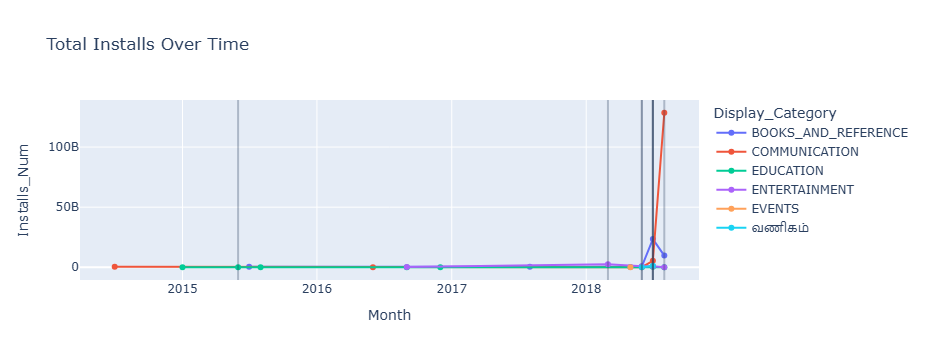

In [67]:
from datetime import datetime

current_hour = datetime.now().hour

if 18 <= current_hour < 21:

    # Convert Period values in the graph's X-axis
    for trace in fig.data:
        if trace.x is not None:
            trace.x = [str(x) for x in trace.x]

    # Convert Period values used in graph shapes
    for shape in fig.layout.shapes:
        if shape.x0 is not None:
            shape.x0 = str(shape.x0)

        if shape.x1 is not None:
            shape.x1 = str(shape.x1)

    fig.show()

else:
    print(
        "This graph is available only between 6 PM IST and 9 PM IST."
    )

In [68]:
monthly_installs["Month"] = (
    monthly_installs["Month"].astype(str)
)
monthly_installs.dtypes

Month                     str
Display_Category          str
Installs_Num            int64
Growth_Percentage     float64
Significant_Growth       bool
dtype: object

In [69]:
fig = px.line(
    monthly_installs,
    x="Month",
    y="Installs_Num",
    color="Display_Category",
    markers=True,
    title="Total Installs Over Time"
)

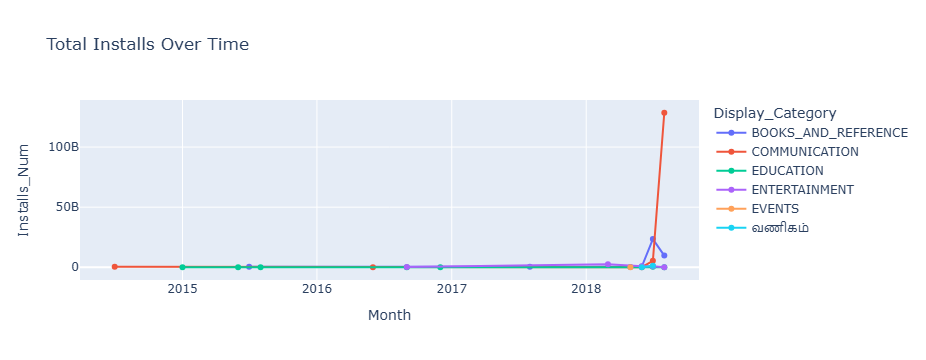

In [70]:
current_hour = 19

if 18 <= current_hour < 21:
    fig.show()
else:
    print(
        "This graph is available only between 6 PM IST and 9 PM IST."
    )

In [71]:
monthly_installs[
    monthly_installs["Significant_Growth"] == True
]

,Month,Display_Category,Installs_Num,Growth_Percentage,Significant_Growth
13,2018-06,BOOKS_AND_REFERENCE,585000000,200.000000,True
17,2018-07,BOOKS_AND_REFERENCE,23437000000,3906.324786,True
14,2018-06,COMMUNICATION,70000000,6900.000000,True
18,2018-07,COMMUNICATION,5334000000,7520.000000,True
23,2018-08,COMMUNICATION,128550000000,2310.011249,True
2,2015-06,EDUCATION,35000000,845.945946,True
19,2018-07,EDUCATION,350000000,43650.000000,True
10,2018-03,ENTERTAINMENT,2400000000,900.000000,True
21,2018-07,வணிகம்,1170000000,3242.857143,True


In [72]:
current_hour = 17
if 18 <= current_hour < 21:
    fig.show()
else:
    print(
        "This graph is available only between 6 PM IST and 9 PM IST."
    )

This graph is available only between 6 PM IST and 9 PM IST.


In [73]:
current_hour = 21
if 18 <= current_hour < 21:
    fig.show()
else:
    print(
        "This graph is available only between 6 PM IST and 9 PM IST."
    )

This graph is available only between 6 PM IST and 9 PM IST.


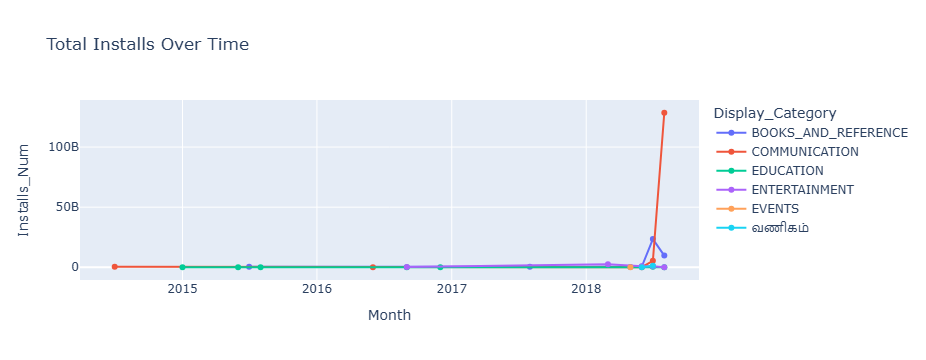

In [74]:
current_hour = 20
if 18 <= current_hour < 21:
    fig.show()
else:
    print(
        "This graph is available only between 6 PM IST and 9 PM IST."
    )